<a href="https://colab.research.google.com/github/Raedaloauni/ML_Project_20/blob/main/Credit_Scoring_Version_Finale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">1 : Libraries Import</font></b></h2>
    </td>
  </tr>
</table>

In [1]:
import pandas as pd
''' Pandas is the fundamental library for data manipulation that converts datasets
    into interactive tables called DataFrames, allowing for efficient
    cleaning, filtering, and analysis of large-scale data '''

import matplotlib.pyplot as plt
'''Matplotlib is the foundation library for data visualization in Python,
   to explore data distributions and model performance '''
'''Pyplot is a sub-module of Matplotlib designed to make the creation
   of plots much simpler and faster'''

import warnings
warnings.filterwarnings('ignore')
'''The warnings module is used to handle warning messages, and filterwarnings('ignore')
   ensures a cleaner output by hiding non-critical alerts,
   such as future software updates or minor calculation notices '''

print("Libraries successfully imported ")

Libraries successfully imported 


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, accuracy_score, average_precision_score)

''' sklearn : It handles three vital functions:

    --> Training (Apprentissage): It analyzes historical data (past bank customers) to recognize patterns:
        example : I notice that customers with high debt and low income tend to default.

    --> Prediction (Prédiction): Once it has learned, you provide data for a new customer it has never seen,
        and it estimates: "Based on what I know, there is a 90% probability this customer will repay."

    --> Evaluation (Évaluation): It is capable of self-assessment to tell you
        if it has become an expert or if it is still making too many mistakes  '''

print("Libraries successfully imported ")

Libraries successfully imported 


In [3]:
from imblearn.over_sampling import SMOTE
'''In credit project, the majority of people repay their loans (0) while only a minority defaults (1).
   If our model sees 95% of '0', it will become lazy and predict '0' all the time.
   SMOTE creates synthetic examples of defaulting customers to balance the dataset
   and force the model to effectively learn both cases '''

from xgboost import XGBClassifier

import joblib
'''Once our model has finished learning, we don't want to restart the process every time.
   => Joblib allows you to save our model into a file.
      Later, we can 'defrost' it to use it instantly in a real-world application '''

print("Libraries successfully imported")

Libraries successfully imported


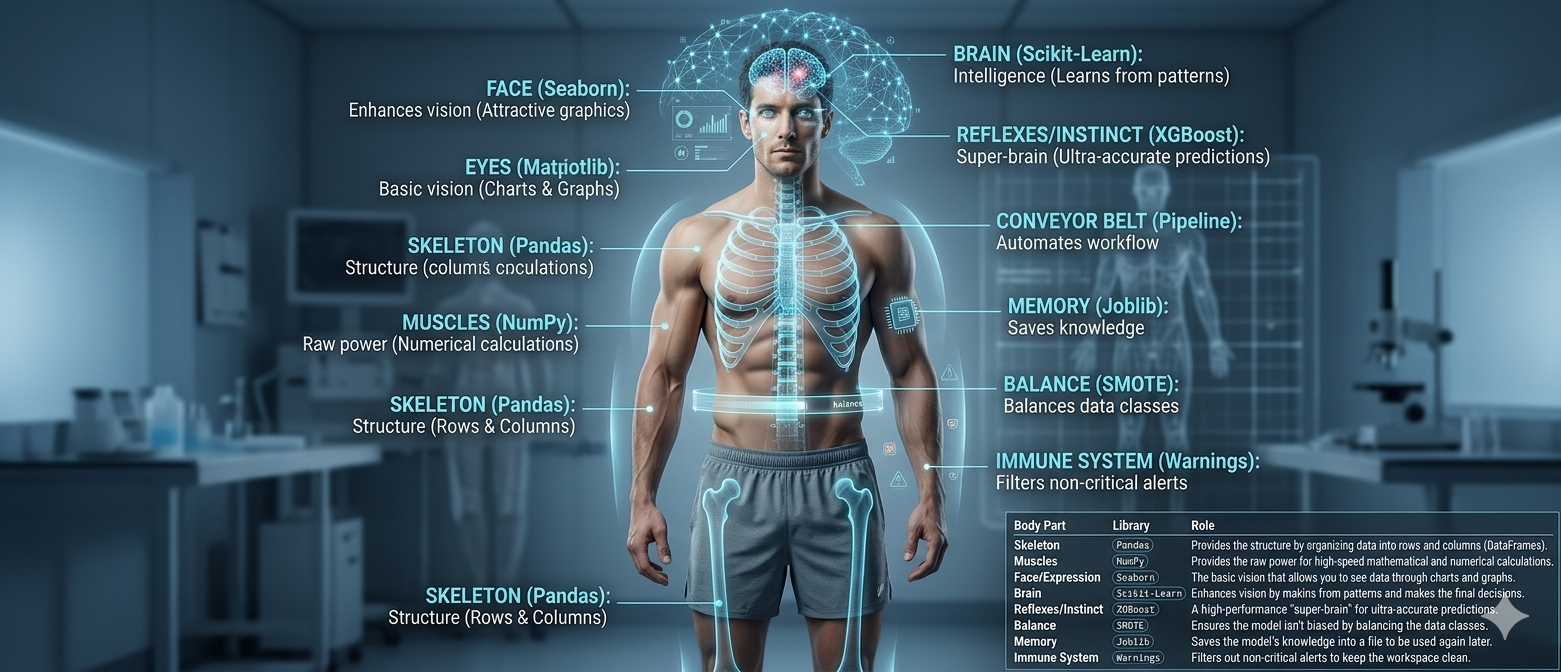

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">2 : Exploratory Data Analysis (EDA) : Data</font></b></h2>
    </td>
  </tr>
</table>

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">2.1 : Loading Data</font></b></h2>
    </td>
  </tr>
</table>

In [4]:
df = pd.read_csv('GiveMeSomeCredit.csv', index_col=0)


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">2.2 : Data Exploration</font></b></h2>
    </td>
  </tr>
</table>




In [5]:
df.shape

(150000, 11)

In [6]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### Dataset Variables Categorization

| Category | Variable Name | Description |
| :--- | :--- | :--- |
| **1. The Target** (The Goal) | `SeriousDlqin2yrs` | **1** if the customer had a 90+ days delinquency (Default), **0** if they are a good payer. |
| **2. Customer Profile** | `age` | Age of the borrower in years. |
| **2. Customer Profile** | `MonthlyIncome` | Monthly gross income (Note: Contains missing values). |
| **2. Customer Profile** | `NumberOfDependents` | Number of family dependents (children, spouse, etc.). |
| **3. Credit History** | `DebtRatio` | Monthly debt payments divided by monthly gross income. |
| **3. Credit History** | `NumberOfOpenCreditLinesAndLoans` | Total number of open loans (car, credit cards, etc.). |
| **3. Credit History** | `NumberRealEstateLoansOrLines` | Number of mortgage and real estate loans. |
| **3. Credit History** | `RevolvingUtilization` | Percentage of total credit limit currently being used. |
| **4. Red Flags** (Past Behavior) | `NumberOfTime30-59DaysPastDue` | Count of 1-2 month payment delays in the last 2 years. |
| **4. Red Flags** (Past Behavior) | `NumberOfTime60-89DaysPastDue` | Count of 2-3 month payment delays in the last 2 years. |
| **4. Red Flags** (Past Behavior) | `NumberOfTimes90DaysLate` | Count of 3+ month payment delays (Highest risk indicator). |

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">2.3 : General information</font></b></h2>
    </td>
  </tr>
</table>




In [7]:
df.info()
#This command answers three key questions:
#   --> How many rows do we have? (example  150,000 entries)
#      This tells you the total volume of our dataset.
#   --> Are there missing values? If a column shows a lower count than the others,
#      it means there are empty cells (known as NaN or Null values).
#   --> What are the data types?  int64 or float64: These are numbers, which are perfect for mathematical calculations and machine learning'''

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">2.4 : Descriptive statistics</font></b></h2>
    </td>
  </tr>
</table>




In [8]:
df.describe().round(2)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


###  Important Remark: Mean vs. Median

* **If Mean $\approx$ Median:** The data is balanced and "healthy" (follows a Normal Distribution or "Bell Curve"). There are no extreme values pulling the average.
* **If Mean $>$ Median:** The data is **Right-Skewed**. This means you have a few **"Giants" (Outliers)** pulling the average up.
    * *Example in our project:* In `MonthlyIncome`, our Mean is **$6,670** but our Median is only **$5,400**. This proves that a few very high salaries are inflating the average.
* **If Mean $<$ Median:** The data is **Left-Skewed**, meaning a few extremely low values are pulling the average down.

> **Why it matters:** Most Machine Learning models (like XGBoost or Logistic Regression) can be sensitive to these "Giants." Identifying them now helps us decide if we need to scale or cap these values later.

| Category | Observation | Problem Found | Action Required |
| :--- | :--- | :--- | :--- |
| **1. Target** | `SeriousDlqin2yrs` | Only 7% default rate. | **Balance**: Use SMOTE later to avoid bias. |
| **2. Profile** | `MonthlyIncome` | ~30,000 missing values. | **Imputation**: Fill gaps with the Median. |
| **2. Profile** | `age` | Minimum age is 0. | **Cleaning**: Remove the row with age 0. |
| **3. History** | `RevolvingUtilization`| Max is 50,708 (should be ~1). | **Capping**: Limit extreme values (Outliers). |
| **4. Red Flags** | `NumberOfTime...` | Maximum value is 98 delays. | **Filtering**: Treat "98" as a code for "Unknown". |

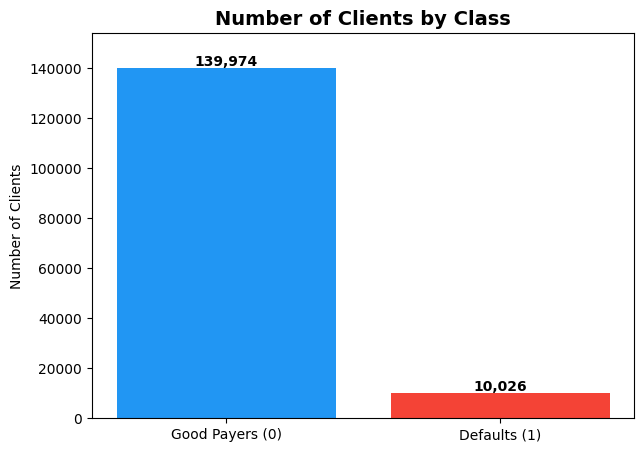

Imbalance Ratio: 14.0 to 1


In [9]:
target_counts = df['SeriousDlqin2yrs'].value_counts()
plt.figure(figsize=(7, 5))
colors = ['#2196F3', '#F44336'] # Bleu (0) et Rouge (1)

bars = plt.bar(['Good Payers (0)', 'Defaults (1)'], target_counts.values, color=colors)

#  Adding numbers above the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1000,
             f'{int(height):,}', ha='center', fontweight='bold')

# Graphic dressing

plt.title('Number of Clients by Class', fontsize=14, fontweight='bold')
plt.ylabel('Number of Clients')
plt.ylim(0, max(target_counts.values) * 1.1) # Provide space for the text
plt.show()

print(f"Imbalance Ratio: {target_counts[0]/target_counts[1]:.1f} to 1")

Missing Values Summary:
                    Missing Count  Percentage (%)
MonthlyIncome               29731           19.82
NumberOfDependents           3924            2.62


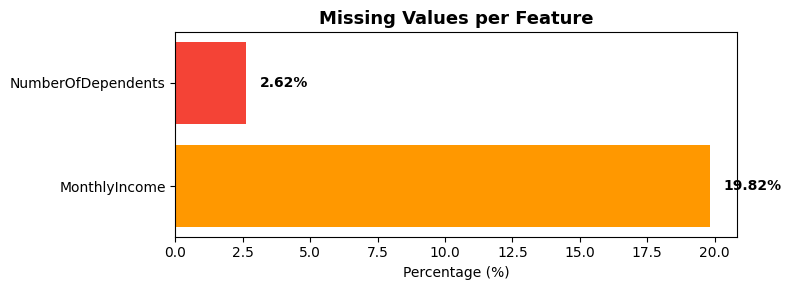

In [10]:
# Missing values analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Create a summary DataFrame
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print("Missing Values Summary:")
print(missing_df)

# Horizontal Bar Chart
fig, ax = plt.subplots(figsize=(8, 3))
colors = ['#FF9800', '#F44336'] # Orange and Red

bars = ax.barh(missing_df.index, missing_df['Percentage (%)'], color=colors)
ax.set_xlabel('Percentage (%)')
ax.set_title('Missing Values per Feature', fontsize=13, fontweight='bold')

# Add labels on the bars
for bar, val in zip(bars, missing_df['Percentage (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">3 : Data Preprocessing (Prétraitement des Données)</font></b></h2>
    </td>
  </tr>
</table>

## Strategy

To ensure our model is accurate and robust, we will follow this four-step preprocessing pipeline:

| Strategy | Concept | Why it matters |
| :--- | :--- | :--- |
| **1. Median Imputation** | Filling empty cells (**NaN**) with the middle value of the column. | **Outlier-resistant:** Unlike the Mean, the Median isn't dragged away by extreme salaries, making it a "fairer" replacement for missing data. |
| **2. 99th Percentile Capping** | Capping extreme values (Outliers) at the 99% threshold (Winsorization). | **Stability:** Prevents the model from "going crazy" due to unrealistic figures (like a 300,000% Debt Ratio) while still keeping the signal that the value is high. |
| **3. SMOTE Resampling** | Creating synthetic "clones" of the minority class (Defaults). | **Balance:** Our dataset only has 6.7% defaults. SMOTE forces the model to learn the characteristics of bad payers as much as good payers. |
| **4. StandardScaler** | Scaling all features to a mean of 0 and a variance of 1. | **Fairness:** Ensures that large numbers (e.g., $10,000 Income) don't overpower smaller numbers (e.g., 45 years old) during the model's calculation. |

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.1 : Copy of the dataset</font></b></h2>
    </td>
  </tr>
</table>






In [11]:
data = df.copy()


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.2 : Imputation by the median</font></b></h2>
    </td>
  </tr>
</table>




In [12]:
for col in ['MonthlyIncome', 'NumberOfDependents']:
    median_val = data[col].median()
    data[col].fillna(median_val, inplace=True)
    #The role of fillna is to replace missing or null values (NaN) with a specific "filler" value
    #so that our dataset is complete and ready for mathematical calculations.

    print(f" {col} : {data[col].isnull().sum()} missing values (médiane = {median_val:.0f})")

 MonthlyIncome : 0 missing values (médiane = 5400)
 NumberOfDependents : 0 missing values (médiane = 0)


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.3 : Capping of outliers (99th percentile)</font></b></h2>
    </td>
  </tr>
</table>




### Outlier Capping (The "Giant" Adjustment)

To prevent extreme values from distorting our model, we applied **99th Percentile Capping**.

#### **The Classroom Analogy:**
Imagine measuring the heights of students in a classroom:
* **Normal range:** Most students are between **150cm and 190cm**.
* **The Outlier:** One record says a student is **50,000cm** tall (likely a data entry error or a massive extreme).

**The Problem:** If you keep the 50,000cm, your "Average" height becomes thousands of centimeters, which is a **false reality**.

**The Solution (Capping):**
1. We find the **99th percentile** (the "ceiling"), let's say it's **195cm**.
2. We "clip" the 50,000cm student down to **195cm**.
3. **The Result:** We still record that this student is among the tallest, but they no longer "break" the mathematical calculations of our model.

> **Applied to our data:** This fixes extreme `DebtRatio` and `MonthlyIncome` values, making the features more stable for Machine Learning.

In [13]:
# List of columns to treat for outliers
outlier_cols = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome',
                'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse',
                'NumberOfTime60-89DaysPastDueNotWorse']

# Apply 99th percentile capping (Winsorization)
for col in outlier_cols:
    cap = data[col].quantile(0.99)
    data[col] = data[col].clip(upper=cap)

# Verification prints
print("\n Outlier capping completed.")
print(f"\nFinal Shape: {data.shape}")
print(f"Missing Values: {data.isnull().sum().sum()}")


 Outlier capping completed.

Final Shape: (150000, 11)
Missing Values: 0



<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.4 : Separate features and target variable</font></b></h2>
    </td>
  </tr>
</table>




In [14]:
X = data.drop('SeriousDlqin2yrs', axis=1)
y = data['SeriousDlqin2yrs']

print(f"Features: {X.shape[1]} columns")
print(f"Total Samples: {X.shape[0]:,} rows")
print(f"\nFeatures being used:")
for col in X.columns:
    print(f"  - {col}")

Features: 10 columns
Total Samples: 150,000 rows

Features being used:
  - RevolvingUtilizationOfUnsecuredLines
  - age
  - NumberOfTime30-59DaysPastDueNotWorse
  - DebtRatio
  - MonthlyIncome
  - NumberOfOpenCreditLinesAndLoans
  - NumberOfTimes90DaysLate
  - NumberRealEstateLoansOrLines
  - NumberOfTime60-89DaysPastDueNotWorse
  - NumberOfDependents




To train our model, we need to separate our data just like preparing for an exam:

* **X (The Workbook):** These are the exercises. It contains all the features (Age, Income, Debt Ratio, etc.) that the model will study. We **drop** the answer column so the model can't "cheat."
* **y (The Answer Key):** these are the solutions. It contains only the `SeriousDlqin2yrs` column. We keep this separate so we can check if the model's guesses are correct later.

| Component | Variable | Data Content |
| :--- | :--- | :--- |
| **Exercises** | **X** | 10 Features (Age, MonthlyIncome, etc.) |
| **Solutions** | **y** | 1 Target Column (Default: Yes/No) |


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.5 : Train/Test split</font></b></h2>
    </td>
  </tr>
</table>




In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {X_train.shape[0]:,} exemples")
print(f"Test  : {X_test.shape[0]:,} exemples")
print(f"\nDistribution train : {y_train.value_counts().to_dict()}")
print(f"Distribution test  : {y_test.value_counts().to_dict()}")

Train : 120,000 exemples
Test  : 30,000 exemples

Distribution train : {0: 111979, 1: 8021}
Distribution test  : {0: 27995, 1: 2005}



<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">3.6 : Train/Test split</font></b></h2>
    </td>
  </tr>
</table>




In [16]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE :")
print(f"  Train : {X_train_sm.shape[0]:,} examples ({pd.Series(y_train_sm).value_counts().to_dict()})")


After SMOTE :
  Train : 223,958 examples ({0: 111979, 1: 111979})


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">4 : Model Training and Comparison</font></b></h2>
    </td>
  </tr>
</table>

We are comparing 4 models covering different algorithmic families to find the most accurate predictor:

| Model | Family | Advantages |
| :--- | :--- | :--- |
| **Logistic Regression** | Linear | Interpretable, fast, and serves as a solid baseline. |
| **Random Forest** | Ensemble (Bagging) | Robust and excellent at handling non-linear relationships. |
| **XGBoost** | Ensemble (Boosting) | Highly performant and specialized in handling class imbalances. |
| **KNN** | Instance-based | Simple, intuitive, and non-parametric. |


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">4.1 : Normalisation</font></b></h2>
    </td>
  </tr>
</table>




> ### The "Equalizer" (Normalization)
>
> **"This code acts as the 'Equalizer.' It ensures that features with large numbers (like an income of $10,000) don't 'bully' features with small numbers (like an age of 45 or 2 children)."**
>
> ---
> **Why we do this:** Machine Learning models are essentially large calculators. By scaling all features to a similar range (Mean = 0, Standard Deviation = 1), we ensure the algorithm judges every variable based on its actual importance rather than its numerical size.

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">4.2 : Definition of models




</font></b></h2>
    </td>
  </tr>
</table>




In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                         use_label_encoder=False, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">4.3 : Training and evaluation
</font></b></h2>
    </td>
  </tr>
</table>




In [19]:
results = {}
for name, model in models.items():
    X_tr = X_train_scaled if name in ['Logistic Regression', 'KNN'] else X_train_sm
    X_te = X_test_scaled  if name in ['Logistic Regression', 'KNN'] else X_test

    model.fit(X_tr, y_train_sm)
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'auc':      roc_auc_score(y_test, y_proba),
        'f1':       f1_score(y_test, y_pred),
        'ap':       average_precision_score(y_test, y_proba),
    }
    print(f" {name:<22} | AUC: {results[name]['auc']:.4f} | F1: {results[name]['f1']:.4f} | Acc: {results[name]['accuracy']:.4f}")


 Logistic Regression    | AUC: 0.8451 | F1: 0.3002 | Acc: 0.7641
 Random Forest          | AUC: 0.8215 | F1: 0.3484 | Acc: 0.8924
 XGBoost                | AUC: 0.8083 | F1: 0.3292 | Acc: 0.8742
 KNN                    | AUC: 0.7782 | F1: 0.2797 | Acc: 0.7813


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">5 : Comparative Analysis of Results
</font></b></h2>
    </td>
  </tr>
</table>


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">5.1 : Performance Summary Table
</font></b></h2>
    </td>
  </tr>
</table>




In [20]:

results_df = pd.DataFrame({
    name: {
        'Accuracy':      f"{v['accuracy']:.4f}",
        'AUC-ROC':       f"{v['auc']:.4f}",
        'F1-Score':      f"{v['f1']:.4f}",
        'Avg Precision': f"{v['ap']:.4f}",
    }
    for name, v in results.items()
}).T

results_df.index.name = 'Model'
print("=== Baseline Model Comparison ===")
print(results_df.to_string())

=== Baseline Model Comparison ===
                    Accuracy AUC-ROC F1-Score Avg Precision
Model                                                      
Logistic Regression   0.7641  0.8451   0.3002        0.3656
Random Forest         0.8924  0.8215   0.3484        0.2524
XGBoost               0.8742  0.8083   0.3292        0.2585
KNN                   0.7813  0.7782   0.2797        0.1817


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">5.2 : Performance Bar Charts
</font></b></h2>
    </td>
  </tr>
</table>

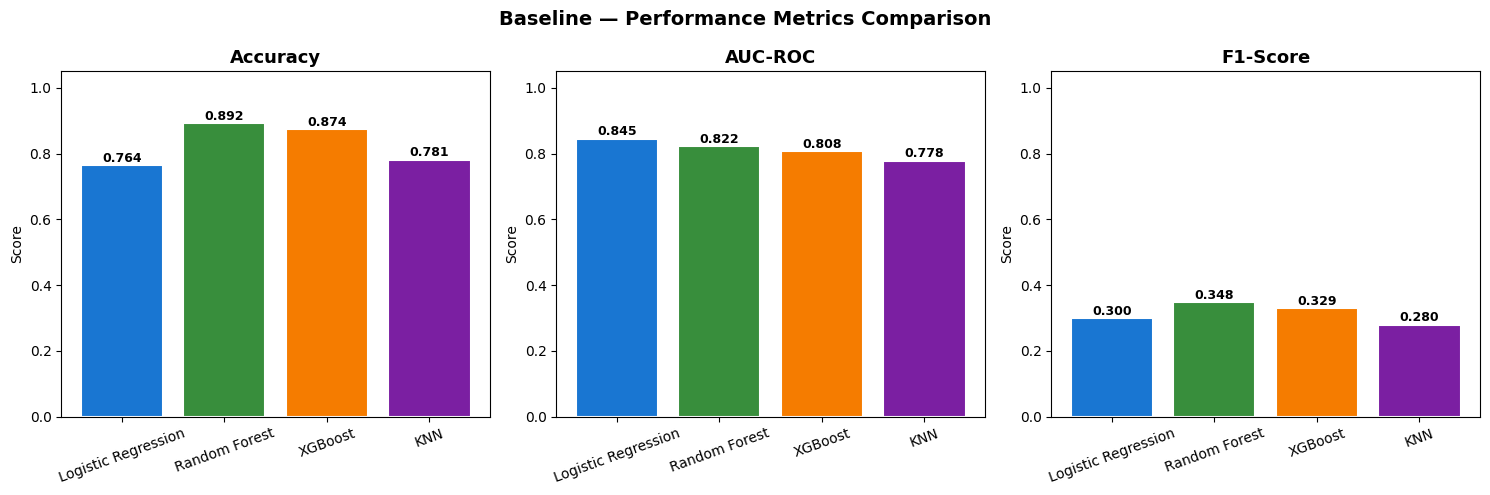

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics       = ['accuracy', 'auc', 'f1']
metric_labels = ['Accuracy', 'AUC-ROC', 'F1-Score']
colors        = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']
model_names   = list(results.keys())

for ax, metric, label in zip(axes, metrics, metric_labels):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Baseline — Performance Metrics Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">5.3 : ROC & Precision-Recall Curves
</font></b></h2>
    </td>
  </tr>
</table>

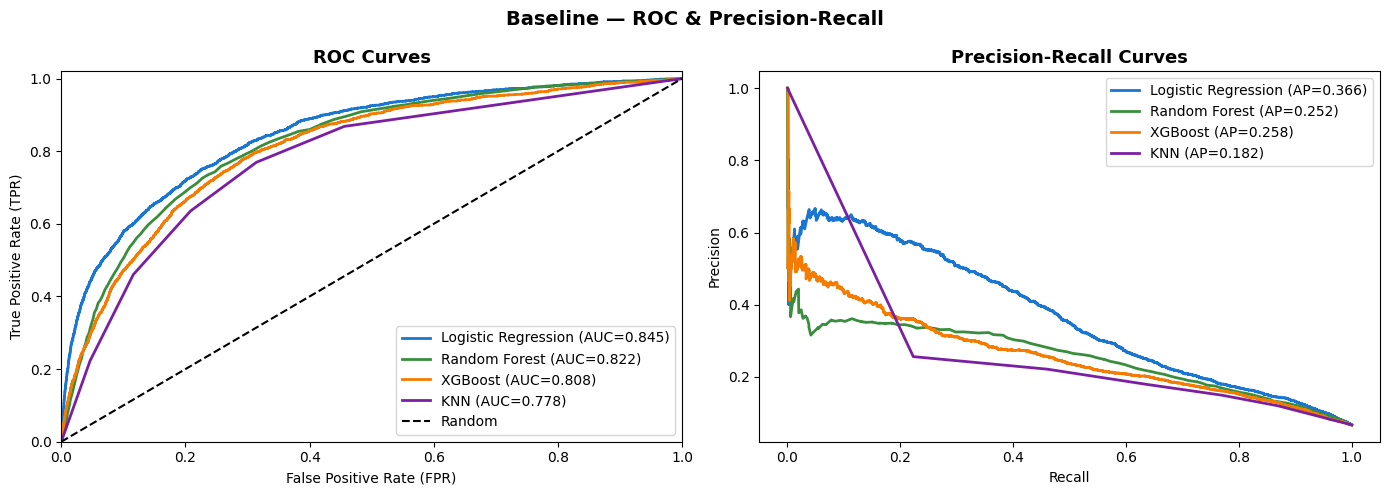

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_roc = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

# ROC Curve
ax = axes[0]
for (name, v), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={v['auc']:.3f})", color=color, lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curves', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

# Precision-Recall Curve
ax = axes[1]
for (name, v), color in zip(results.items(), colors_roc):
    precision, recall, _ = precision_recall_curve(y_test, v['y_proba'])
    ax.plot(recall, precision, label=f"{name} (AP={v['ap']:.3f})", color=color, lw=2)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')

plt.suptitle('Baseline — ROC & Precision-Recall', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">5.4 : Confusion Matrices (Best Baseline vs Logistic Regression)
</font></b></h2>
    </td>
  </tr>
</table>

Best baseline model (by AUC): Logistic Regression


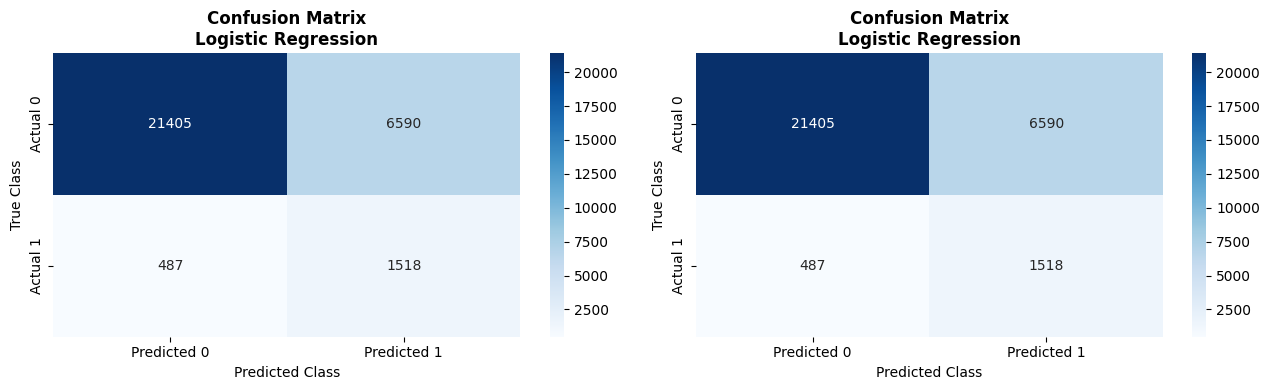

In [24]:
import seaborn as sns
best_baseline_name = max(results, key=lambda x: results[x]['auc'])
print(f"Best baseline model (by AUC): {best_baseline_name}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, v) in zip(axes, [
    (best_baseline_name, results[best_baseline_name]),
    ('Logistic Regression', results['Logistic Regression'])
]):
    cm = confusion_matrix(y_test, v['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    ax.set_title(f'Confusion Matrix\n{name}', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Class')
    ax.set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()


<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="blue">5.5 : Feature Importance : Logistic Regression
</font></b></h2>
    </td>
  </tr>
</table>

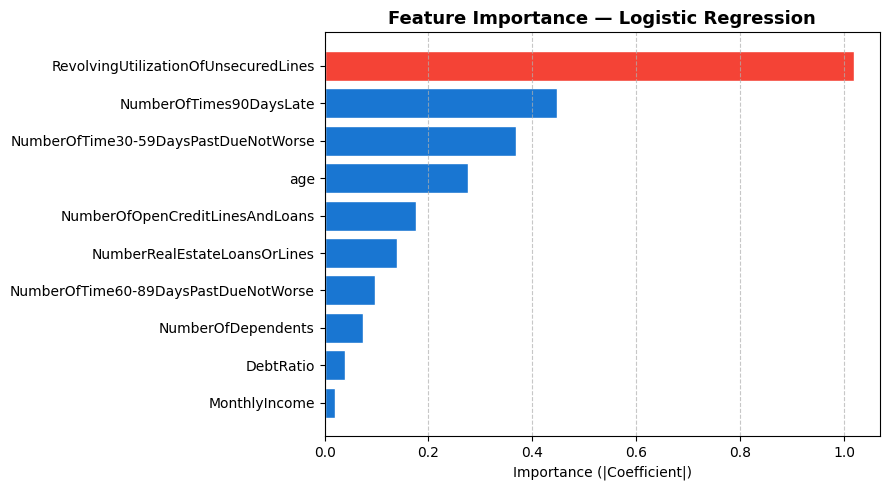


Top 5 Most Important Features:
  RevolvingUtilizationOfUnsecuredLines          1.0184
  NumberOfTimes90DaysLate                       0.4481
  NumberOfTime30-59DaysPastDueNotWorse          0.3685
  age                                           0.2764
  NumberOfOpenCreditLinesAndLoans               0.1762


In [25]:
log_model = results['Logistic Regression']['model']
feat_imp  = pd.Series(log_model.coef_[0], index=X.columns).abs().sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors_imp = ['#F44336' if v == feat_imp.max() else '#1976D2' for v in feat_imp.values]
plt.barh(feat_imp.index, feat_imp.values, color=colors_imp, edgecolor='white')
plt.xlabel('Importance (|Coefficient|)')
plt.title('Feature Importance — Logistic Regression', fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
for feat, val in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<45} {val:.4f}")

<table bgcolor="#D3D3D3" width="100%">
  <tr>
    <td align="left">
      <h2><b><font color="purple">6 : Model Optimization : XGBoost GridSearchCV : Hyperparameter Tuning (GridSearchCV)
</font></b></h2>
    </td>
  </tr>
</table>

In [26]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample':     [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    verbose=1
)

grid_search.fit(X_train_sm, y_train_sm)  # tree-based model → no scaling needed

print(f"Best AUC (CV): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

best_xgb = grid_search.best_estimator_


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best AUC (CV): 0.9534
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
